In [36]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
from attr.filters import exclude

# Reading data

In [37]:
with open('data/v_3.json', 'r', encoding='utf-8') as file:
    raw_data = json.load(file)

# checking data structure
print(type(raw_data))
print(raw_data.keys())

# transforming to DataFrame
columns = raw_data['columns']
data = raw_data['data']

df = pd.DataFrame(data, columns=columns)
print(df.head())


<class 'dict'>
dict_keys(['columns', 'index', 'data'])
   Unnamed: 0       open_SAR  open_USD       high_SAR  high_USD  \
0  2021-01-30  128437.248512  34246.28  131012.723200  34933.00   
1  2021-01-29  125144.022272  33368.18  144510.037760  38531.90   
2  2021-01-28  113870.357376  30362.19  126703.438592  33783.98   
3  2021-01-27  121753.023104  32464.01  122102.860416  32557.29   
4  2021-01-26  120966.114176  32254.19  123470.218752  32921.88   

         low_SAR   low_USD      close_SAR  close_USD    volume  
0      123106.88  32825.00  128333.212416   34218.54   43072.0  
1   119695.51616  31915.40  128459.450880   34252.20  231827.0  
2   111919.81184  29842.10  125131.570944   33364.86   92621.0  
3  109668.146688  29241.72  113885.208960   30366.15   95911.0  
4  115652.472448  30837.37  121767.124608   32467.77   84972.0  


# Normalize data

In [38]:
print(df.isnull().sum())

# transforming columns to dtypes
df['open_SAR'] = pd.to_numeric(df['open_SAR'], errors='coerce')
df['open_USD'] = pd.to_numeric(df['open_USD'], errors='coerce')
df['high_SAR'] = pd.to_numeric(df['high_SAR'], errors='coerce')
df['high_USD'] = pd.to_numeric(df['high_USD'], errors='coerce')
df['low_SAR'] = pd.to_numeric(df['low_SAR'], errors='coerce')
df['low_USD'] = pd.to_numeric(df['low_USD'], errors='coerce')
df['close_SAR'] = pd.to_numeric(df['close_SAR'], errors='coerce')
df['close_USD'] = pd.to_numeric(df['close_USD'], errors='coerce')
df['volume'] = pd.to_numeric(df['volume'], errors='coerce')
df['date'] = pd.to_datetime(df['Unnamed: 0'], errors='coerce')

print(df.info())

Unnamed: 0    0
open_SAR      5
open_USD      4
high_SAR      4
high_USD      5
low_SAR       4
low_USD       4
close_SAR     4
close_USD     4
volume        6
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1012 entries, 0 to 1011
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Unnamed: 0  1012 non-null   object        
 1   open_SAR    1006 non-null   float64       
 2   open_USD    1008 non-null   float64       
 3   high_SAR    1008 non-null   float64       
 4   high_USD    1007 non-null   float64       
 5   low_SAR     1007 non-null   float64       
 6   low_USD     1008 non-null   float64       
 7   close_SAR   1008 non-null   float64       
 8   close_USD   1008 non-null   float64       
 9   volume      1006 non-null   float64       
 10  date        1012 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(9), object(1)
memory usage: 87.1+ KB
None


# filling data

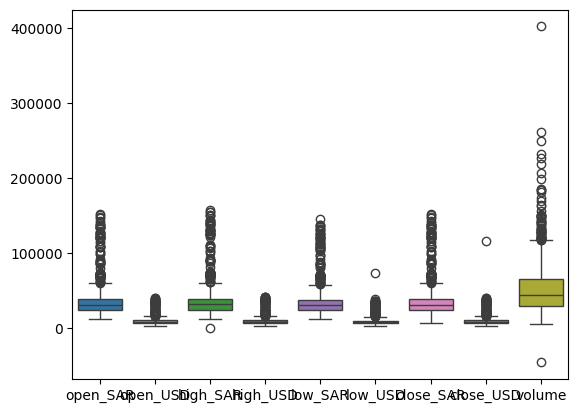

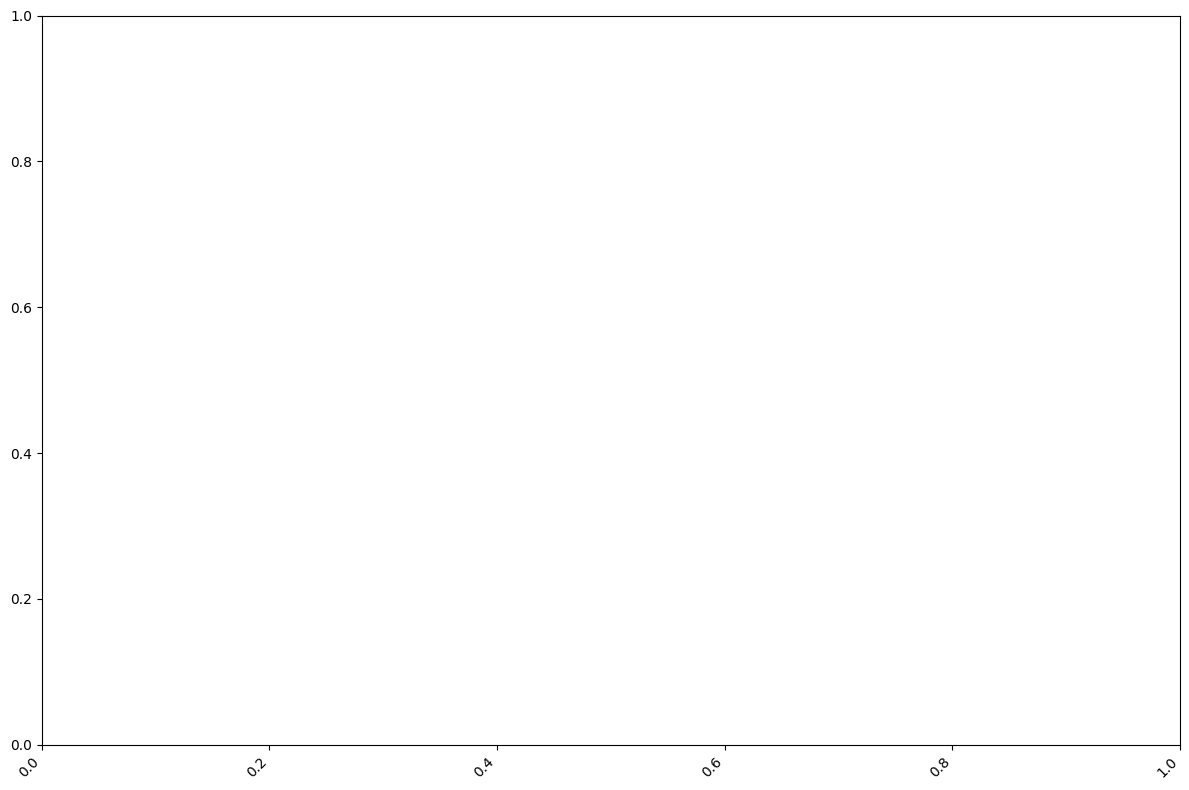

In [39]:
numeric_columns = df.select_dtypes(include=['number']).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

sns.boxplot(data=df)
plt.figure(figsize=(12, 8))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()